# Introduction

Dataset from: https://www.kaggle.com/datasets/wafaaelhusseini/capital-weather-data-1995-2024

Daily historical weather data for major cities worldwide from 1995 to 2024.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data processing

In [4]:
df = pd.read_parquet("history.parquet")

n_rows = len(df)
cols = list(df.columns)

print(f"We have {n_rows} rows in total\n")
print(f"We have these {cols}\n")
print(f"Datatypes of all columns:\n{df.dtypes}\n")

# adapt datatypes
df['date'] = pd.to_datetime(df['date'])

# Example of rows
print(df.head(5))

We have 1796746 rows in total

We have these ['date', 'country', 'country_alpha2', 'capital', 'lat', 'lon', 'temp_min_c', 'temp_max_c', 'temp_mean_c_approx', 'app_temp_min_c', 'app_temp_max_c', 'precip_mm', 'rain_mm', 'snow_mm', 'windspeed_10m_max_kmh', 'windgusts_10m_max_kmh', 'wind_dir_dom_deg', 'sunshine_duration_s', 'daylight_duration_s', 'shortwave_radiation_MJ_m2']

Datatypes of all columns:
date                          object
country                       object
country_alpha2                object
capital                       object
lat                          float64
lon                          float64
temp_min_c                   float64
temp_max_c                   float64
temp_mean_c_approx           float64
app_temp_min_c               float64
app_temp_max_c               float64
precip_mm                    float64
rain_mm                      float64
snow_mm                      float64
windspeed_10m_max_kmh        float64
windgusts_10m_max_kmh        float64
wind_di

Let's analyze the cities we have. First verify if we have just one city per country or maybe for some countries we have multiple cities.

In [5]:
# Group cities by country
cities_per_country = df.groupby('country')['capital'].unique()

# Find countries with multiple capitals
countries_with_multiple_cities = cities_per_country[cities_per_country.apply(len) > 1]

print(f"Countries with more than one capital: {len(countries_with_multiple_cities)}\n")

print(f"Total countries: {df['country'].nunique()}\n")
print(f"Total capitals: {df['capital'].nunique()}")

Countries with more than one capital: 0

Total countries: 164

Total capitals: 164


We may have not the data for all the cities...

In [6]:
num_different_cities = df['capital'].nunique()
print(f"Number of different cities: {num_different_cities}")

city_counts = df['capital'].value_counts()
print(f"Number of rows per city {city_counts}\n")

max_count = city_counts.max()
cities_not_max = city_counts[city_counts != max_count]
print(f"Maximum number of rows per city: {max_count}\n")
print(f"Cities with number of rows != from max: {len(cities_not_max)} over {num_different_cities}\n")
print(f"And it is: {cities_not_max}\n")

Number of different cities: 164
Number of rows per city capital
Kabul               10958
Tirana              10958
Algiers             10958
Andorra la Vella    10958
Luanda              10958
                    ...  
Philipsburg         10958
Bratislava          10958
Ljubljana           10958
Honiara             10958
Mogadishu           10592
Name: count, Length: 164, dtype: int64

Maximum number of rows per city: 10958

Cities with number of rows != from max: 1 over 164

And it is: capital
Mogadishu    10592
Name: count, dtype: int64



Mogadishu has less data. Let's analyze what dates it is missing.

In [7]:
# Find first and last dates
first_date = df['date'].min()
last_date = df['date'].max()

print(f"First date: {first_date}")
print(f"Last date: {last_date}")
print(f"Total date: {df['date'].nunique()}")

days_difference = (last_date - first_date).days
print(f"Days from first to last date: {days_difference}")
#if days_difference = total_dates - 1 no days skipped

First date: 1995-01-01 00:00:00
Last date: 2024-12-31 00:00:00
Total date: 10958
Days from first to last date: 10957


Okay, dataset is complete of dates: all days from 01/01/1995 to 31/12/2024.

Mogadishu has 10592 dates
Missing 366 dates out of 10958

First 10 missing dates:
DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10'],
              dtype='datetime64[ns]', freq='D')

Last 10 missing dates:
DatetimeIndex(['2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27', '2024-12-28', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', freq='D')


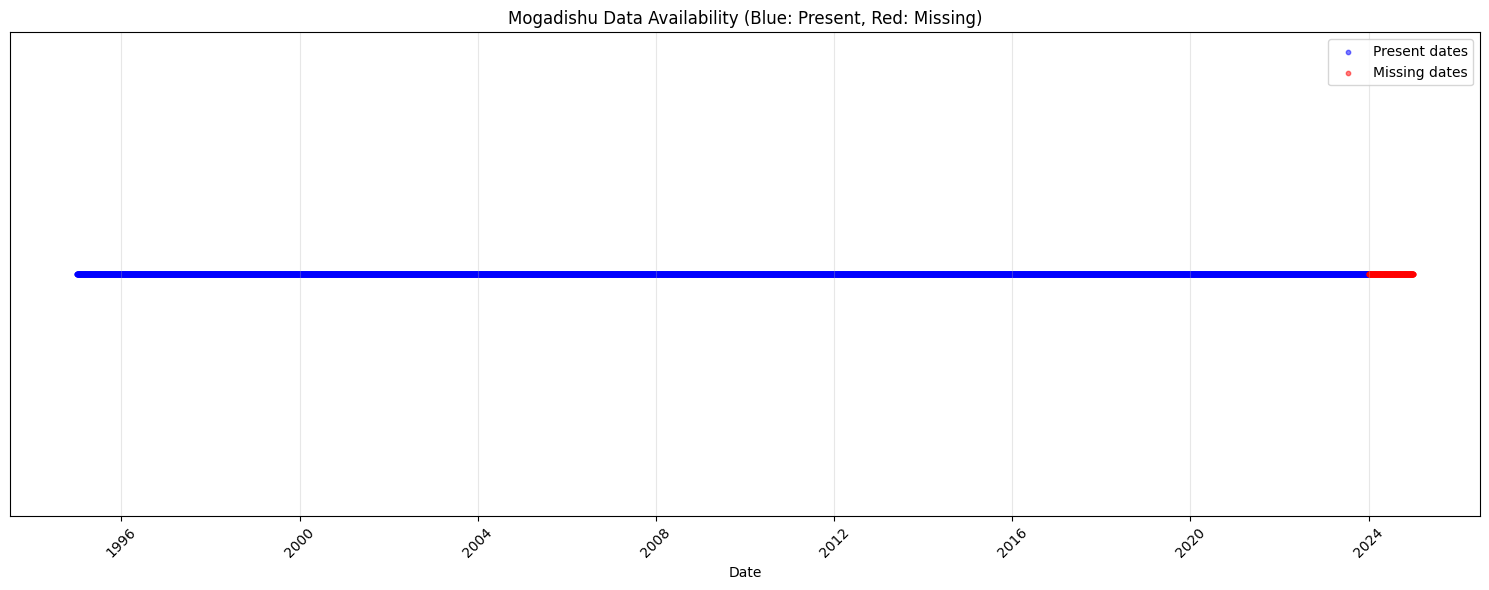

In [8]:
# Get all dates for Mogadishu
mogadishu_dates = df[df['capital'] == 'Mogadishu']['date'].unique()

# Create a complete date range
all_dates = pd.date_range(start=first_date, end=last_date, freq='D')

# Find missing dates
missing_dates = all_dates.difference(mogadishu_dates)
present_dates = all_dates.difference(missing_dates)

print(f"Mogadishu has {len(mogadishu_dates)} dates")
print(f"Missing {len(missing_dates)} dates out of {len(all_dates)}")
print(f"\nFirst 10 missing dates:")
print(missing_dates[:10])
print(f"\nLast 10 missing dates:")
print(missing_dates[-10:])

plt.figure(figsize=(15, 6))

# Plot present dates in blue
plt.scatter(present_dates, [1]*len(present_dates), alpha=0.5, s=10, c='blue', label='Present dates')

# Plot missing dates in red
plt.scatter(missing_dates, [1]*len(missing_dates), alpha=0.5, s=10, c='red', label='Missing dates')

plt.xlabel('Date')
plt.ylabel('')
plt.title('Mogadishu Data Availability (Blue: Present, Red: Missing)')
plt.yticks([])
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Mogadishu the entire date from 2024. To have consistent result we avoid it from our dataset.

In [9]:
# Remove all rows for Mogadishu
df = df[df['capital'] != 'Mogadishu']

print(f"After removing Mogadishu, we have {len(df)} rows")
print(f"Number of cities now: {df['capital'].nunique()}")
city_counts_updated = df['capital'].value_counts()
print(f"\nNumber of rows per capital after removing Mogadishu:")
print(city_counts_updated)

print(f"\nAll cities have the same number of rows: {city_counts_updated.nunique() == 1}")

After removing Mogadishu, we have 1786154 rows
Number of cities now: 163

Number of rows per capital after removing Mogadishu:
capital
Kabul               10958
Tirana              10958
Algiers             10958
Andorra la Vella    10958
Luanda              10958
                    ...  
Singapore           10958
Philipsburg         10958
Bratislava          10958
Ljubljana           10958
Honiara             10958
Name: count, Length: 163, dtype: int64

All cities have the same number of rows: True


Data cleaning: veryfing if some values are missing

In [10]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nPercentage of missing values per column:")
print((df.isnull().sum() / len(df)) * 100)

# Total missing values
total_missing = df.isnull().sum().sum()
print(f"\nTotal missing values in dataset: {total_missing}")


Missing values per column:
date                         0
country                      0
country_alpha2               0
capital                      0
lat                          0
lon                          0
temp_min_c                   0
temp_max_c                   0
temp_mean_c_approx           0
app_temp_min_c               0
app_temp_max_c               0
precip_mm                    0
rain_mm                      0
snow_mm                      0
windspeed_10m_max_kmh        0
windgusts_10m_max_kmh        0
wind_dir_dom_deg             0
sunshine_duration_s          0
daylight_duration_s          0
shortwave_radiation_MJ_m2    0
dtype: int64

Percentage of missing values per column:
date                         0.0
country                      0.0
country_alpha2               0.0
capital                      0.0
lat                          0.0
lon                          0.0
temp_min_c                   0.0
temp_max_c                   0.0
temp_mean_c_approx           0.0
a

Dataset is clean. No need of further modification.

Now I add season column allowing for precise analysis and I remove other irrelevant columns.

In [11]:
# Add season column based on month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['date'].dt.month.apply(get_season)
df['temp_variation'] = df['temp_max_c'] - df['temp_min_c']
df = df.drop(columns=['country_alpha2'])



Let's briefly describe the features we have:
- date: the yyyy-mm-dd date of the registration
- country: country of the city we are recording data
- [DROPPED] country_alpha2: a two letter code of the country
- capital: the name of the city we are recording data
- lat: ° of city latitude
- lon: ° of city longitude
- [NEW] season: the information about the season of the date

TEMPERATURE DATA
- temp_min_c: CELSIUS measurement of minimal temperature of the day
- temp_max_c: CELSIUS measurement of maximium temperature of the day
- temp_mean_c_approx: CELSIUS mean temperature of the day
- app_temp_min_c: CELSIUS measurement of minimal APPARENT temperature of the day (temperatura percepita)
- app_temp_max_c: CELSIUS measurement of maximium APPARENT temperature of the day (temperatura percepita)
- [NEW] temp_variation: CELSIUS variation from minimial to maximum temperature of the day

PRECIPITATION DATA
- precip_mm: mm of total preecipitations
- rain_mm: mm of RAIN precipitations
- snow_mm: mm of SNOW precipitations

WIND DATA
- windspeed_10m_max_kmh: maximum wind speed in kmh
- windgusts_10m_max_kmh: maximum speed of a wind gust (brezza)
- wind_dir_dom_deg: dominant wind direction (represented as a degree from 0 to 360)

SOLAR EXPOSURE
- sunshine_duration_s: sunshine duration in seconds (period during which the direct normal solar irradiance exceeds a threshold of 120 W/m^2, amount of time of exposure to sunligh)
- daylight_duration_s: daylight duration in seconds (time between sunrise and sunset)
- shortwave_radiation_MJ_m2: solar radiation received in MegaJoule per m^2 (amount of incoming shortwave solar radiation receivied per squared meter, how much solar energy the surface receives)

In [12]:
cols = list(df.columns)
print(df.head())
print(f"We now have these {cols}\n")

        date      country           capital        lat        lon  temp_min_c  \
0 1995-01-01  Afghanistan             Kabul  34.532778  69.165833       -15.6   
1 1995-01-01      Albania            Tirana  41.328889  19.817778        11.6   
2 1995-01-01      Algeria           Algiers  36.776389   3.058611        12.0   
3 1995-01-01      Andorra  Andorra la Vella  42.507222   1.522222        -6.3   
4 1995-01-01       Angola            Luanda  -8.838333  13.234444        23.0   

   temp_max_c  temp_mean_c_approx  app_temp_min_c  app_temp_max_c  ...  \
0         2.6               -6.50           -20.4            -1.4  ...   
1        15.3               13.45             9.7            13.3  ...   
2        20.9               16.45            10.4            16.6  ...   
3         6.7                0.20           -10.7             4.6  ...   
4        28.8               25.90            27.6            34.0  ...   

   rain_mm  snow_mm  windspeed_10m_max_kmh  windgusts_10m_max_kmh  \

In [13]:
# Final information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1786154 entries, 0 to 1796745
Data columns (total 21 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   date                       datetime64[ns]
 1   country                    object        
 2   capital                    object        
 3   lat                        float64       
 4   lon                        float64       
 5   temp_min_c                 float64       
 6   temp_max_c                 float64       
 7   temp_mean_c_approx         float64       
 8   app_temp_min_c             float64       
 9   app_temp_max_c             float64       
 10  precip_mm                  float64       
 11  rain_mm                    float64       
 12  snow_mm                    float64       
 13  windspeed_10m_max_kmh      float64       
 14  windgusts_10m_max_kmh      float64       
 15  wind_dir_dom_deg           int64         
 16  sunshine_duration_s        float64       

Strange behavior, differently to what could see, precip_mm is not always to sum of rain_mm and snow_mm.

This is because:
- in some situations it's different to categorize if it's raining or snowing
- some precipiations are neither rain nor snow: hail, drizzle, freezing rain, graupel

In [14]:
# Check if precip_mm equals rain_mm + snow_mm
sum_rain_snow = df['rain_mm'] + df['snow_mm']
matches = (df['precip_mm'] == sum_rain_snow).sum()
total = len(df)

print(f"Cases where precip_mm == rain_mm + snow_mm: {matches} out of {total}")
print(f"Percentage: {(matches / total) * 100:.2f}%")

matches = (df['precip_mm'] > sum_rain_snow).sum()

print(f"Cases where precip_mm > rain_mm + snow_mm: {matches} out of {total}")
print(f"Percentage: {(matches / total) * 100:.2f}%")

matches = (df['precip_mm'] < sum_rain_snow).sum()

print(f"Cases where precip_mm < rain_mm + snow_mm: {matches} out of {total}")
print(f"Percentage: {(matches / total) * 100:.2f}%")



Cases where precip_mm == rain_mm + snow_mm: 1723311 out of 1786154
Percentage: 96.48%
Cases where precip_mm > rain_mm + snow_mm: 50501 out of 1786154
Percentage: 2.83%
Cases where precip_mm < rain_mm + snow_mm: 12342 out of 1786154
Percentage: 0.69%


# Data exploration

First of all, some summary statistics of the entire dataset.

In [15]:
print(df.describe())

                      date           lat           lon    temp_min_c  \
count              1786154  1.786154e+06  1.786154e+06  1.786154e+06   
mean   2009-12-31 12:00:00  1.978330e+01  1.651834e+01  1.568983e+01   
min    1995-01-01 00:00:00 -4.128889e+01 -1.718333e+02 -4.400000e+01   
25%    2002-07-02 00:00:00  4.373250e+00 -1.371222e+01  9.500000e+00   
50%    2009-12-31 12:00:00  1.797139e+01  1.708361e+01  1.790000e+01   
75%    2017-07-02 00:00:00  4.189306e+01  4.671000e+01  2.390000e+01   
max    2024-12-31 00:00:00  6.417500e+01  1.784333e+02  3.740000e+01   
std                    NaN  2.457115e+01  6.773873e+01  9.779648e+00   

         temp_max_c  temp_mean_c_approx  app_temp_min_c  app_temp_max_c  \
count  1.786154e+06        1.786154e+06    1.786154e+06    1.786154e+06   
mean   2.315223e+01        1.942103e+01    1.577348e+01    2.400643e+01   
min   -3.720000e+01       -3.925000e+01   -7.710000e+01   -4.320000e+01   
25%    1.810000e+01        1.385000e+01    7.300000

Now visualization of general statistics for numeric columns.

In [14]:
units = {
    'temp_min_c': '°C',
    'temp_max_c': '°C',
    'temp_mean_c_approx': '°C',
    'app_temp_min_c': '°C',
    'app_temp_max_c': '°C',
    'temp_variation': '°C',
    'precip_mm': 'mm',
    'rain_mm': 'mm',
    'snow_mm': 'mm',
    'windspeed_10m_max_kmh': 'km/h',
    'windgusts_10m_max_kmh': 'km/h',
    'wind_dir_dom_deg': '°',
    'sunshine_duration_s': 's',
    'daylight_duration_s': 's',
    'shortwave_radiation_MJ_m2': 'MJ/m²'
}

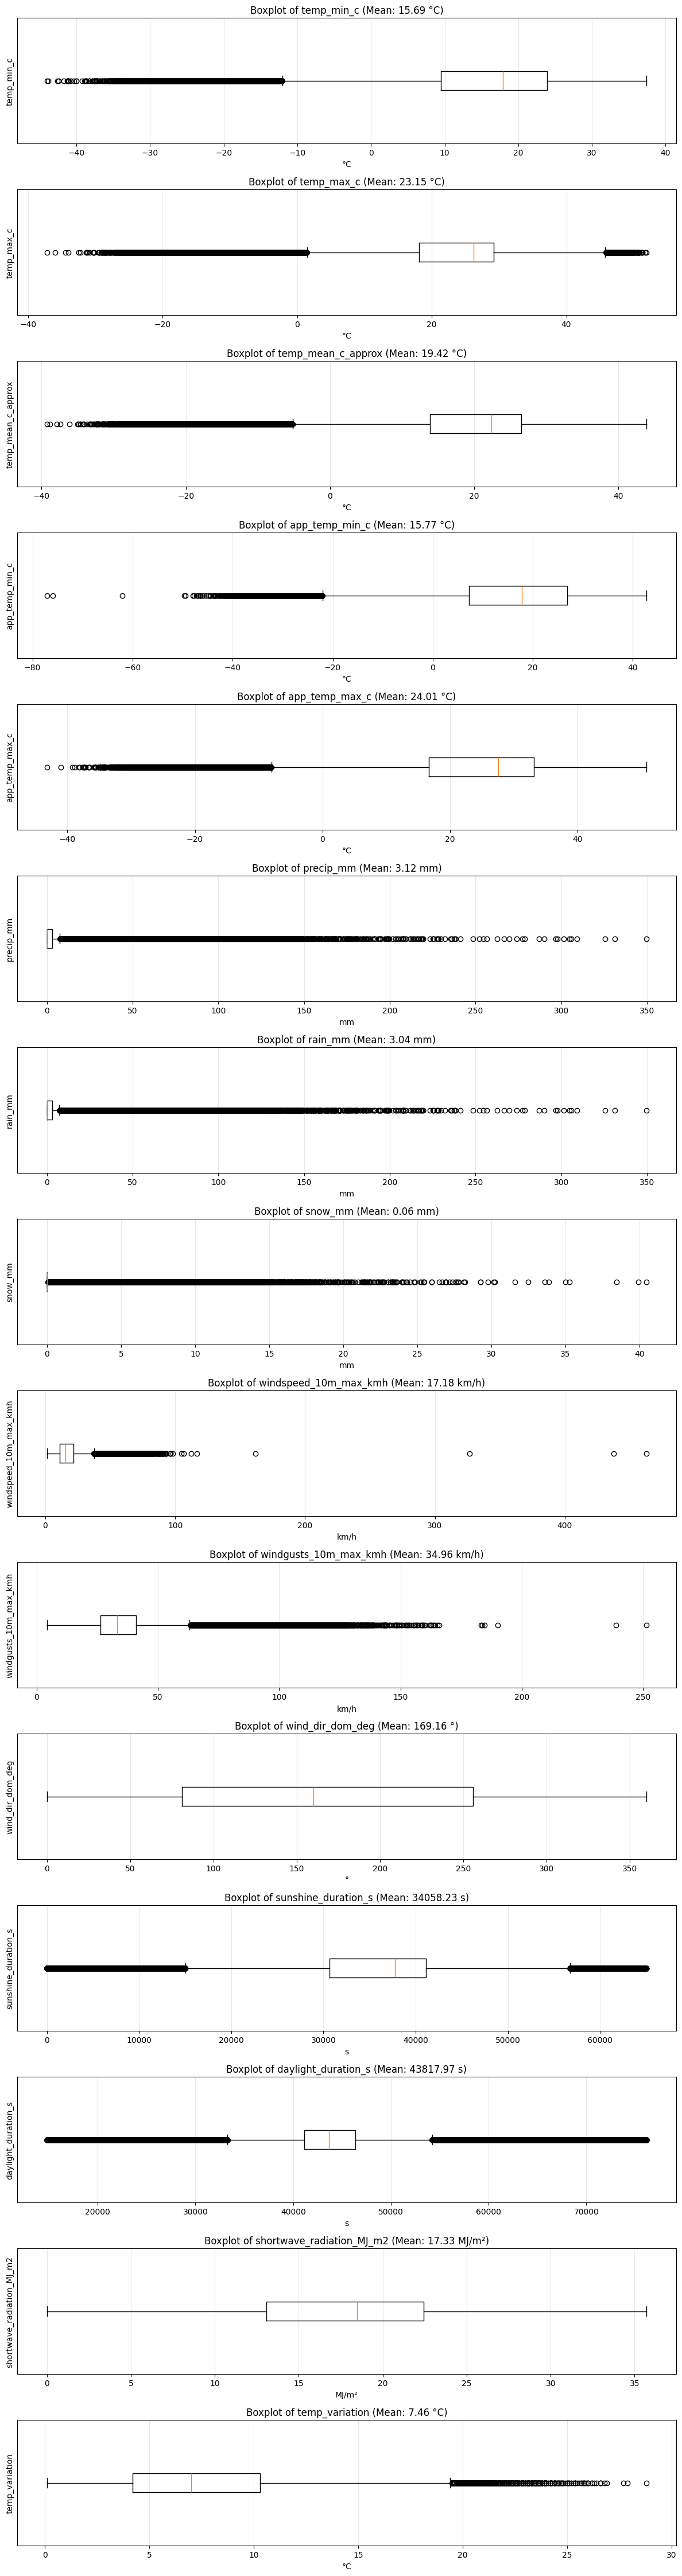

In [15]:
# Get numeric columns excluding lat and lon
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['lat', 'lon']]

# Create boxplots for all numeric columns
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(12, len(numeric_cols) * 3))

# If only one numeric column, axes won't be an array
if len(numeric_cols) == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    mean_val = data.mean()

    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_title(f'Boxplot of {col} (Mean: {mean_val:.2f} {units[col]})')
    axes[i].set_ylabel(col)
    axes[i].set_yticks([])
    axes[i].set_xlabel(units[col])
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Now we analyze correlations with some pairplots!

In [16]:
""" selected_cols = ['temp_mean_c_approx', 'precip_mm', 'sunshine_duration_s',  'shortwave_radiation_MJ_m2']

# Create pairplot
sns.pairplot(df[selected_cols].dropna(), diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Selected Weather Features', y=1.02)
plt.tight_layout()
plt.show() """

" selected_cols = ['temp_mean_c_approx', 'precip_mm', 'sunshine_duration_s',  'shortwave_radiation_MJ_m2']\n\n# Create pairplot\nsns.pairplot(df[selected_cols].dropna(), diag_kind='hist', plot_kws={'alpha': 0.6})\nplt.suptitle('Pairplot of Selected Weather Features', y=1.02)\nplt.tight_layout()\nplt.show() "

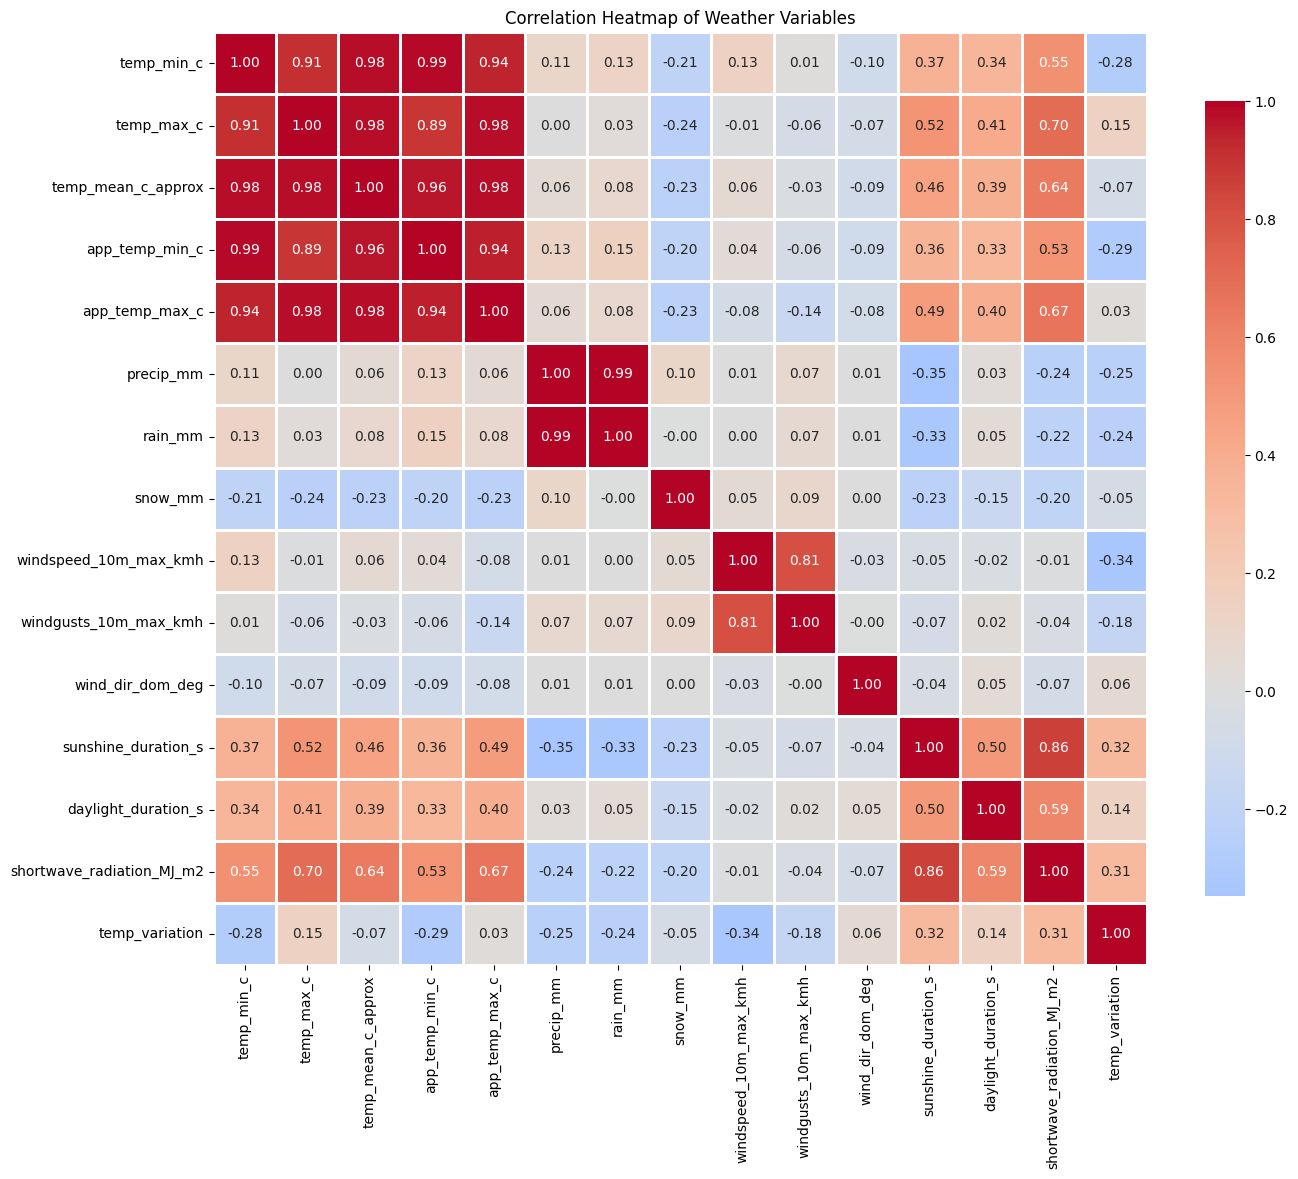

In [17]:
# Correlation heatmap for all numeric columns
plt.figure(figsize=(14, 12))
numeric_df = df[numeric_cols]
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Weather Variables')
plt.tight_layout()
plt.show()

We can see a POSITIVE correlation:
- between shortwave radiation and max temperature
- between shortwave radiation and mean temperature
- between shortwave radiation and sunshine duration
- between shortwave radiation and daylight duration

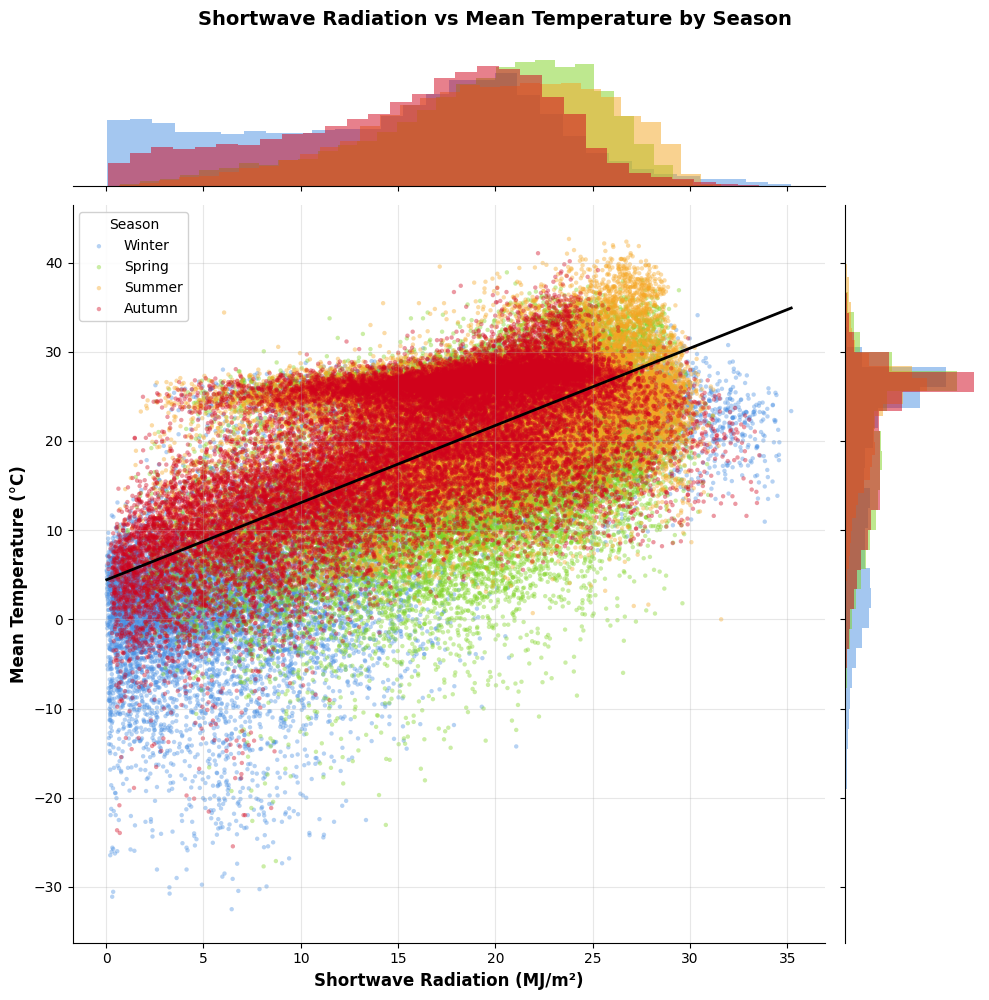

In [18]:
sample_size = 100000
df_sample = df.sample(n=sample_size, random_state=42)

# Define season colors
season_colors = {
    'Winter': '#4A90E2',  # Blue
    'Spring': '#7ED321',  # Green
    'Summer': '#F5A623',  # Orange
    'Autumn': '#D0021B'   # Red
}

# Map colors to the sample
df_sample['color'] = df_sample['season'].map(season_colors)

# Create the jointplot
g = sns.JointGrid(data=df_sample, x='shortwave_radiation_MJ_m2', y='temp_mean_c_approx', height=10)

# Scatter plot colored by season
for season, color in season_colors.items():
    season_data = df_sample[df_sample['season'] == season]
    g.ax_joint.scatter(season_data['shortwave_radiation_MJ_m2'], 
                       season_data['temp_mean_c_approx'],
                       c=color, label=season, alpha=0.4, s=10, edgecolors='none')

# Add regression line
sns.regplot(data=df_sample, x='shortwave_radiation_MJ_m2', y='temp_mean_c_approx',
            scatter=False, ax=g.ax_joint, color='black', line_kws={'linewidth': 2})

# Marginal distributions colored by season
for season, color in season_colors.items():
    season_data = df_sample[df_sample['season'] == season]
    g.ax_marg_x.hist(season_data['shortwave_radiation_MJ_m2'], bins=30, 
                     color=color, alpha=0.5, label=season)
    g.ax_marg_y.hist(season_data['temp_mean_c_approx'], bins=30, 
                     color=color, alpha=0.5, orientation='horizontal')

# Labels and legend
g.ax_joint.set_xlabel('Shortwave Radiation (MJ/m²)', fontsize=12, fontweight='bold')
g.ax_joint.set_ylabel('Mean Temperature (°C)', fontsize=12, fontweight='bold')
g.ax_joint.legend(title='Season', loc='upper left', framealpha=0.9)
g.ax_joint.grid(True, alpha=0.3)

plt.suptitle('Shortwave Radiation vs Mean Temperature by Season', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

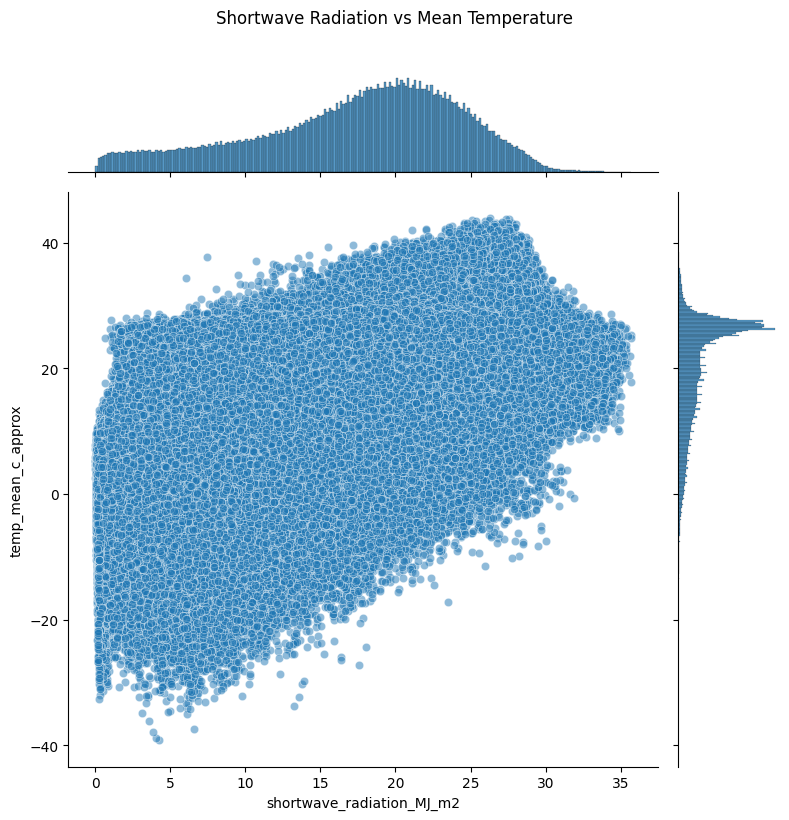

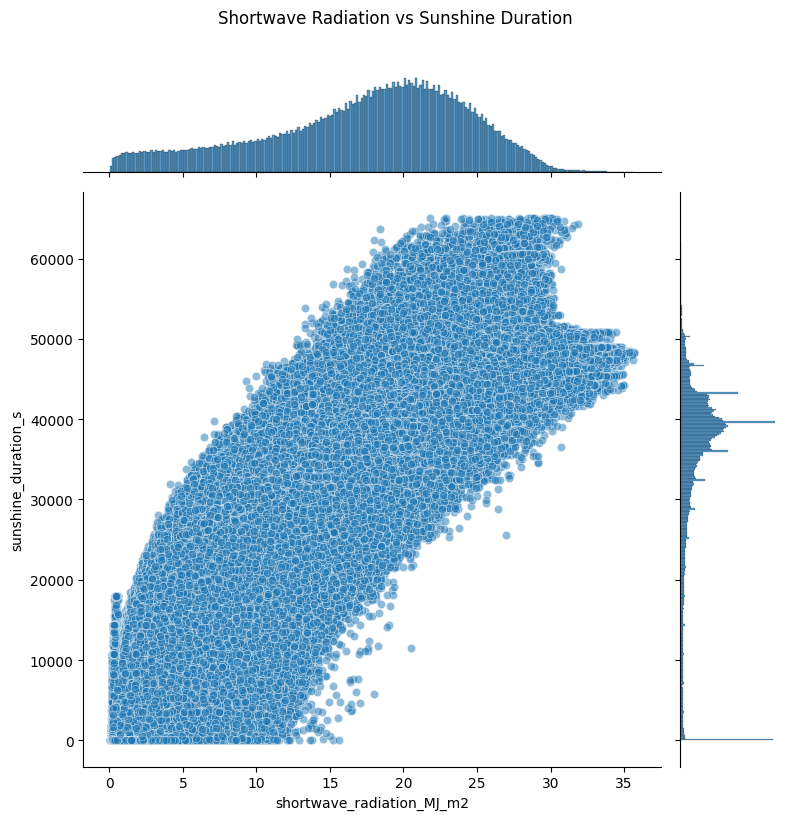

In [19]:
# Jointplot: Shortwave Radiation vs Mean Temperature
sns.jointplot(data=df, x='shortwave_radiation_MJ_m2', y='temp_mean_c_approx', 
              kind='scatter', alpha=0.5, height=8)
plt.suptitle('Shortwave Radiation vs Mean Temperature', y=1.02)
plt.tight_layout()
plt.show()

# Jointplot: Shortwave Radiation vs Sunshine Duration
sns.jointplot(data=df, x='shortwave_radiation_MJ_m2', y='sunshine_duration_s', 
              kind='scatter', alpha=0.5, height=8)
plt.suptitle('Shortwave Radiation vs Sunshine Duration', y=1.02)
plt.tight_layout()
plt.show()

We can see a NEGATIVE correlation:
- between preicp_mm and sunshine duration
- between rain_mm and sunshine duration
- between snow_mm and sunshine duration
- between preicp_mm and shortwave radiation

C:\Users\gabri\AppData\Local\Temp\ipykernel_21772\4262315109.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='season', y='temp_mean_c_approx', palette=season_colors)


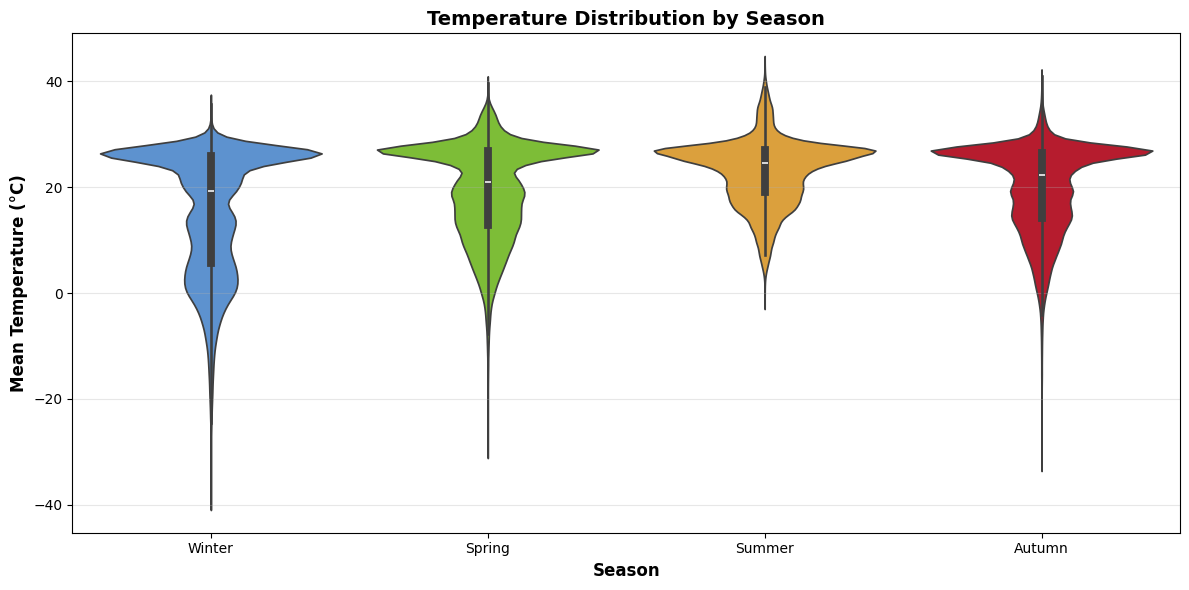

In [20]:
sample_size = 100000
df_sample = df.sample(n=sample_size, random_state=42)

# 1. Violin Plot: Distribution of Temperature across Seasons
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='season', y='temp_mean_c_approx', palette=season_colors)
plt.title('Temperature Distribution by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12, fontweight='bold')
plt.ylabel('Mean Temperature (°C)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

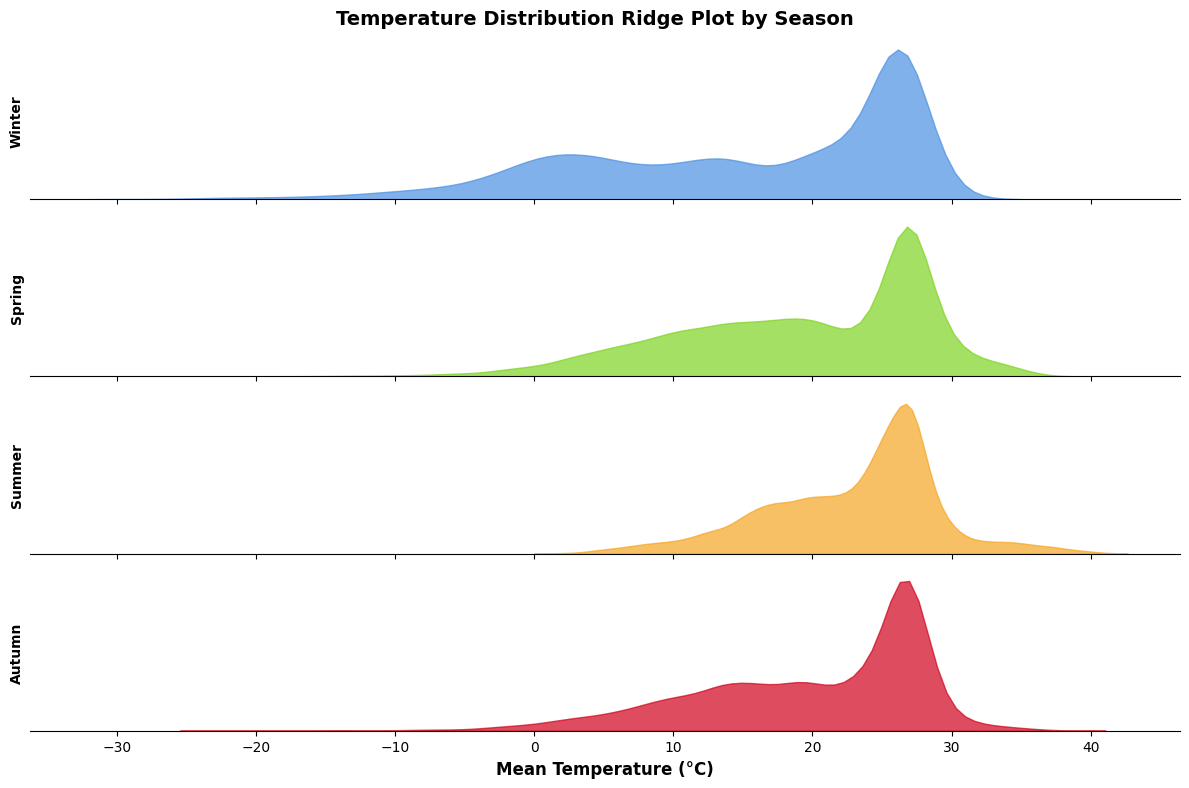

In [21]:
# 3. Ridge Plot: Temperature distribution by season
from scipy import stats
import numpy as np

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
seasons = ['Winter', 'Spring', 'Summer', 'Autumn']

for idx, (season, ax) in enumerate(zip(seasons, axes)):
    data = df_sample[df_sample['season'] == season]['temp_mean_c_approx'].dropna()
    ax.fill_between(np.linspace(data.min(), data.max(), 100),
                     stats.gaussian_kde(data)(np.linspace(data.min(), data.max(), 100)),
                     alpha=0.7, color=season_colors[season])
    ax.set_ylabel(season, fontsize=10, fontweight='bold')
    ax.set_ylim(0, None)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    
axes[-1].set_xlabel('Mean Temperature (°C)', fontsize=12, fontweight='bold')
plt.suptitle('Temperature Distribution Ridge Plot by Season', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


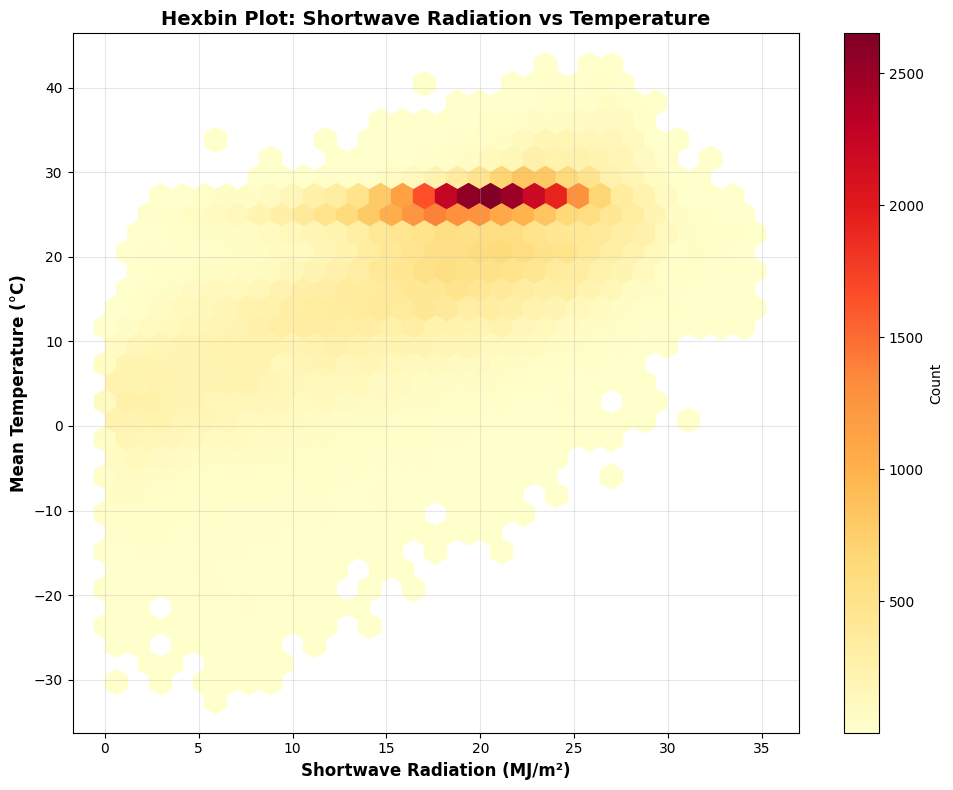

In [22]:
# 4. Hexbin Plot: High-density scatter alternative
plt.figure(figsize=(10, 8))
plt.hexbin(df_sample['shortwave_radiation_MJ_m2'], df_sample['temp_mean_c_approx'], 
           gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Count')
plt.title('Hexbin Plot: Shortwave Radiation vs Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Shortwave Radiation (MJ/m²)', fontsize=12, fontweight='bold')
plt.ylabel('Mean Temperature (°C)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\gabri\AppData\Local\Temp\ipykernel_21772\3943326146.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x='season', y='temp_mean_c_approx', palette=season_colors, ax=axes[0, 0])
C:\Users\gabri\AppData\Local\Temp\ipykernel_21772\3943326146.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x='season', y='precip_mm', palette=season_colors, ax=axes[0, 1])
C:\Users\gabri\AppData\Local\Temp\ipykernel_21772\3943326146.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x='season', y='suns

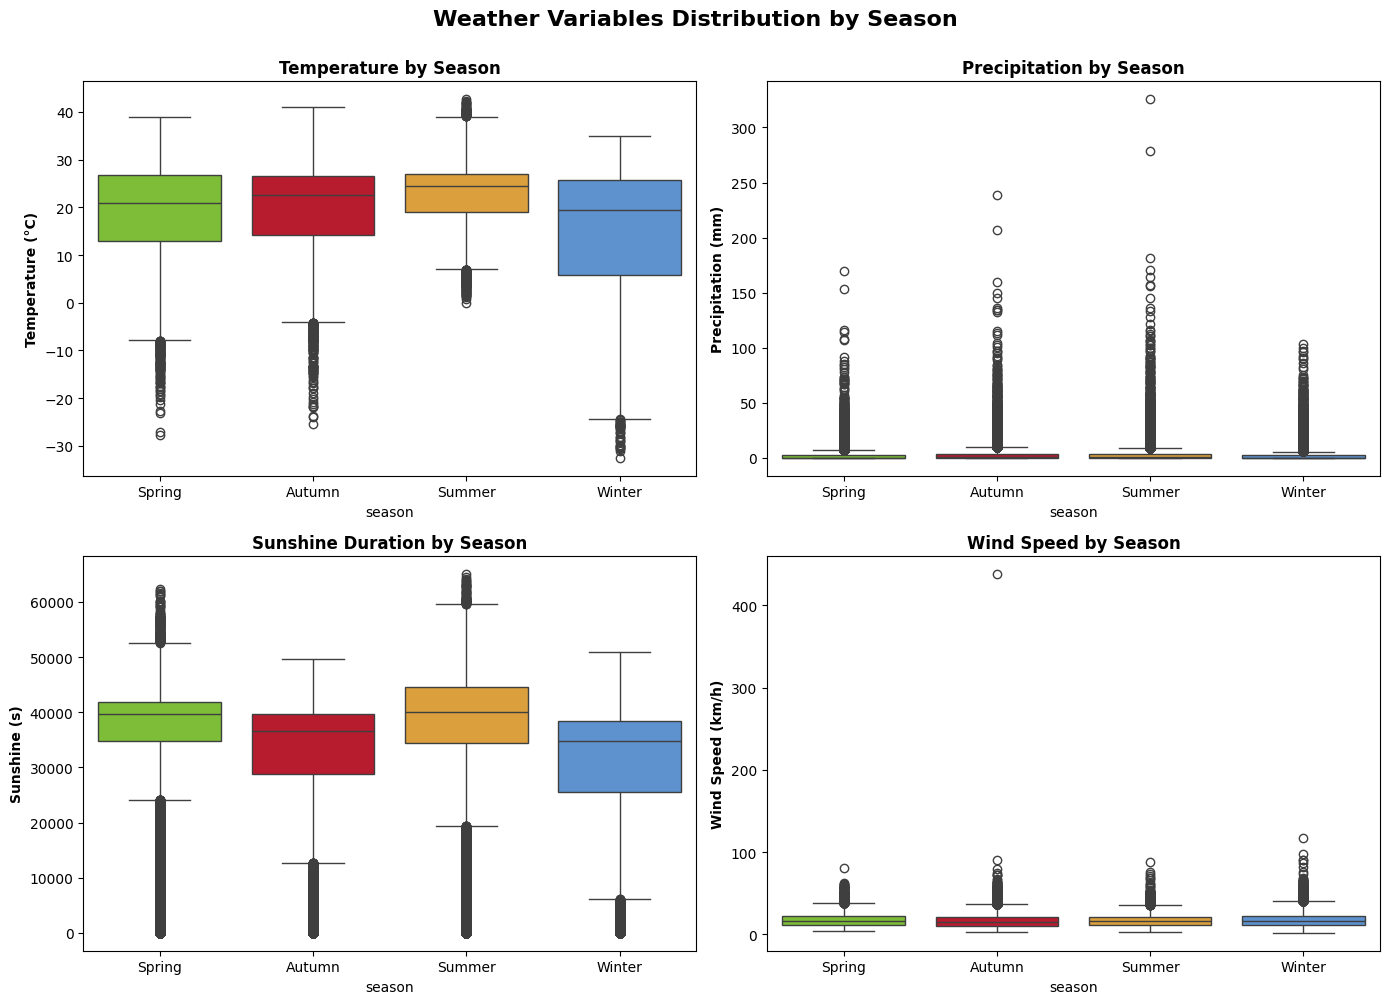

In [23]:
# 5. Box Plot comparison across seasons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Temperature
sns.boxplot(data=df_sample, x='season', y='temp_mean_c_approx', palette=season_colors, ax=axes[0, 0])
axes[0, 0].set_title('Temperature by Season', fontweight='bold')
axes[0, 0].set_ylabel('Temperature (°C)', fontweight='bold')

# Precipitation
sns.boxplot(data=df_sample, x='season', y='precip_mm', palette=season_colors, ax=axes[0, 1])
axes[0, 1].set_title('Precipitation by Season', fontweight='bold')
axes[0, 1].set_ylabel('Precipitation (mm)', fontweight='bold')

# Sunshine Duration
sns.boxplot(data=df_sample, x='season', y='sunshine_duration_s', palette=season_colors, ax=axes[1, 0])
axes[1, 0].set_title('Sunshine Duration by Season', fontweight='bold')
axes[1, 0].set_ylabel('Sunshine (s)', fontweight='bold')

# Wind Speed
sns.boxplot(data=df_sample, x='season', y='windspeed_10m_max_kmh', palette=season_colors, ax=axes[1, 1])
axes[1, 1].set_title('Wind Speed by Season', fontweight='bold')
axes[1, 1].set_ylabel('Wind Speed (km/h)', fontweight='bold')

plt.suptitle('Weather Variables Distribution by Season', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# EDA on few selected cities

In [61]:
cities = ['Rome', 'Abuja', 'Canberra', 'Ottawa', 'Buenos Aires', 'Jakarta', 'Monrovia']

# Filter dataframe to keep only selected cities
df_cities = df[df['capital'].isin(cities)]

#DATA AGGREGATION PER YEAR AND SEASON

# Add year column
df_cities['year'] = df_cities['date'].dt.year

# Aggregate data by city, year and season
city_year_season_stats = df_cities.groupby(['capital', 'year', 'season']).agg({
    'temp_mean_c_approx': 'mean',
    'temp_variation': 'mean',
    'precip_mm': ['sum', 'mean'],
    'sunshine_duration_s': 'mean'
}).round(2)

# Flatten column names
city_year_season_stats.columns = ['_'.join(col).strip() if col[1] else col[0] 
                                   for col in city_year_season_stats.columns.values]

# Rename columns for clarity
city_year_season_stats = city_year_season_stats.rename(columns={
    'temp_mean_c_approx_mean': 'avg_temp_mean_c',
    'temp_variation_mean': 'avg_temp_variation_c',
    'precip_mm_sum': 'total_precip_mm',
    'precip_mm_mean': 'avg_precip_mm',
    'sunshine_duration_s_mean': 'avg_sunshine_duration_s'
})

# Reset index for easier visualization
city_year_season_stats_reset = city_year_season_stats.reset_index()

C:\Users\gabri\AppData\Local\Temp\ipykernel_18672\708899731.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [65]:
#DATA AGGREGATION ONLY PER SEASON

# Aggregate data by city and season
city_season_stats = df_cities.groupby(['capital', 'season']).agg({
    'temp_mean_c_approx': 'mean',
    'temp_variation': 'mean',
    'precip_mm': ['sum', 'mean'],
    'sunshine_duration_s': 'mean'
}).round(2)

# Flatten column names
city_season_stats.columns = ['_'.join(col).strip() if col[1] else col[0] 
                              for col in city_season_stats.columns.values]

# Rename columns for clarity
city_season_stats = city_season_stats.rename(columns={
    'temp_mean_c_approx_mean': 'avg_temp_mean_c',
    'temp_variation_mean': 'avg_temp_variation_c',
    'precip_mm_sum': 'total_precip_mm',
    'precip_mm_mean': 'avg_precip_mm',
    'sunshine_duration_s_mean': 'avg_sunshine_duration_s'
})

# Reset index for easier visualization
city_season_stats_reset = city_season_stats.reset_index()

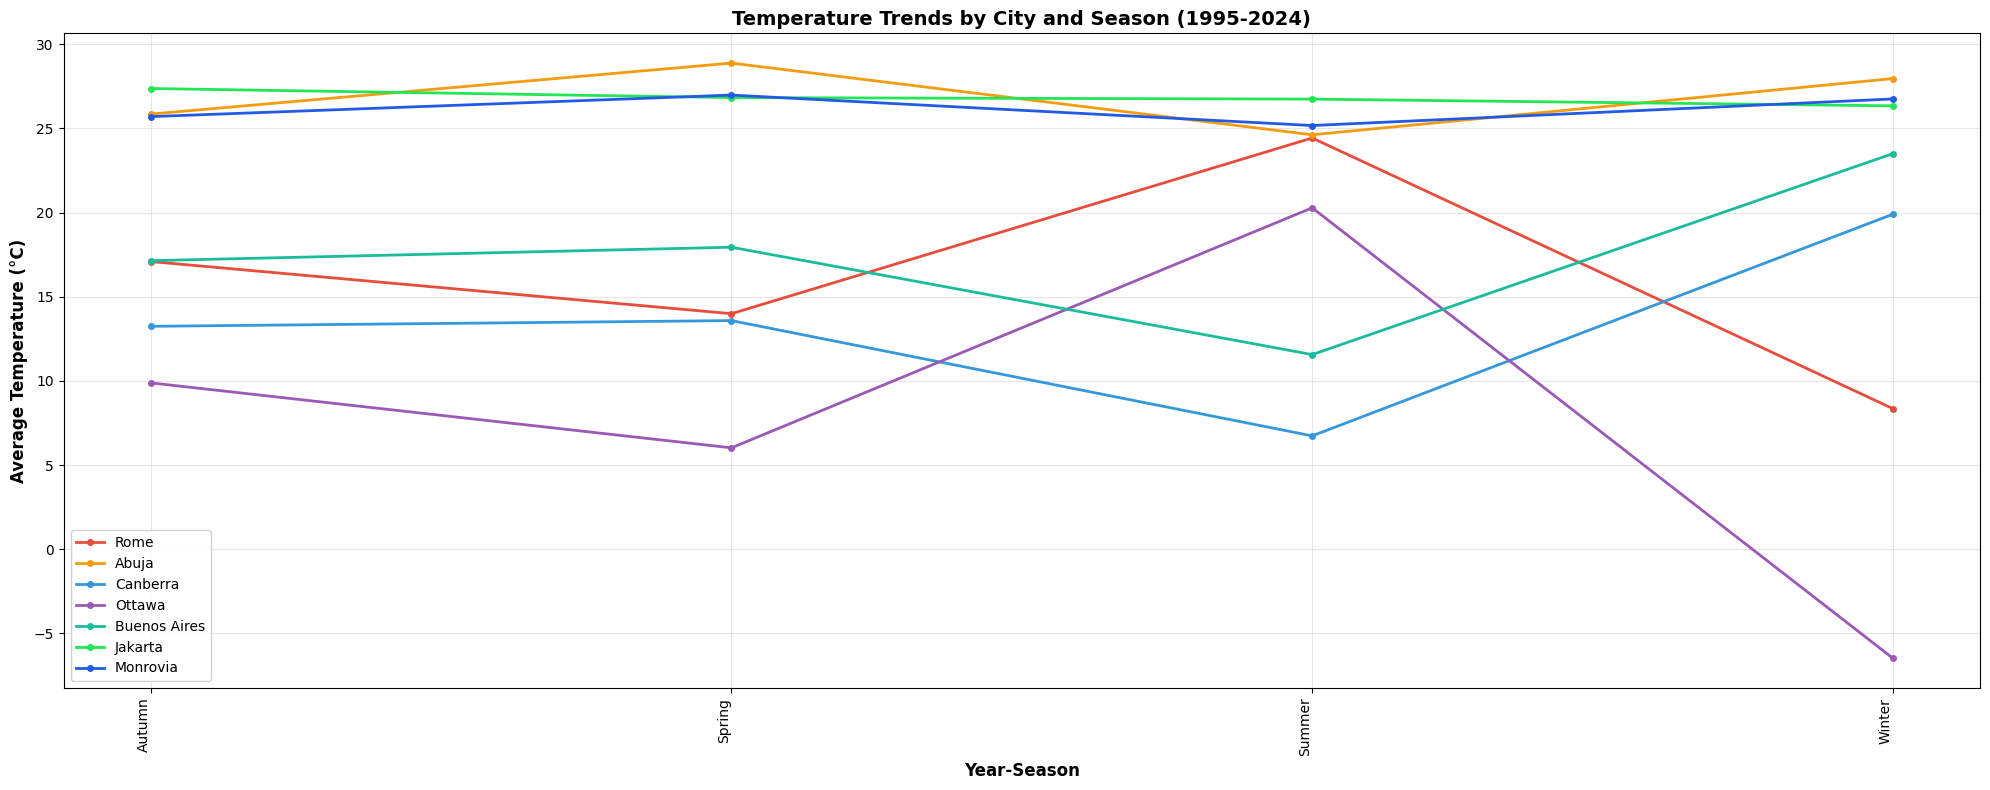

In [ ]:
# Define color palette for cities
city_colors = {
    'Rome': '#E74C3C',
    'Abuja': '#F39C12',
    'Canberra': '#3498DB',
    'Ottawa': '#9B59B6',
    'Buenos Aires': '#1ABC9C',
    'Jakarta': "#22E656",
    'Monrovia': "#225AE6",
}

# Create the plot
plt.figure(figsize=(20, 8))

for city in cities:
    city_data = city_season_stats_reset[city_season_stats_reset['capital'] == city]
    plt.plot(city_data['season'], city_data['avg_temp_mean_c'], 
             marker='o', label=city, linewidth=2, markersize=4,
             color=city_colors.get(city.strip(), None))

plt.xlabel('Season', fontsize=12, fontweight='bold')
plt.ylabel('Average Temperature (°C)', fontsize=12, fontweight='bold')
plt.title('Temperature Trends by City and Season (1995-2024)', fontsize=14, fontweight='bold')
plt.legend(loc='best', framealpha=0.9, fontsize=10)
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90, ha='right')

plt.tight_layout()
plt.show()

In [68]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add a trace for each city
for city in cities:
    city_data = city_year_season_stats_reset[city_year_season_stats_reset['capital'] == city]
    
    fig.add_trace(go.Scatter(
        x=city_data['year_season'],
        y=city_data['avg_temp_mean_c'],
        mode='lines+markers',
        name=city.strip(),
        line=dict(width=2),
        marker=dict(size=6),
        hovertemplate='<b>%{fullData.name}</b><br>Period: %{x}<br>Temperature: %{y:.2f}°C<extra></extra>'
    ))

# Update layout
fig.update_layout(
    title='Temperature Trends by City and Season (1995-2024)',
    xaxis_title='Year-Season',
    yaxis_title='Average Temperature (°C)',
    hovermode='closest',
    height=600,
    width=1400,
    xaxis=dict(tickangle=-90),
    legend=dict(x=1.02, y=1, bordercolor="Black", borderwidth=1)
)

fig.show()

KeyError: 'year_season'

C:\Users\gabri\AppData\Local\Temp\ipykernel_18672\667687528.py:28: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gabri\AppData\Local\Temp\ipykernel_18672\667687528.py:45: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



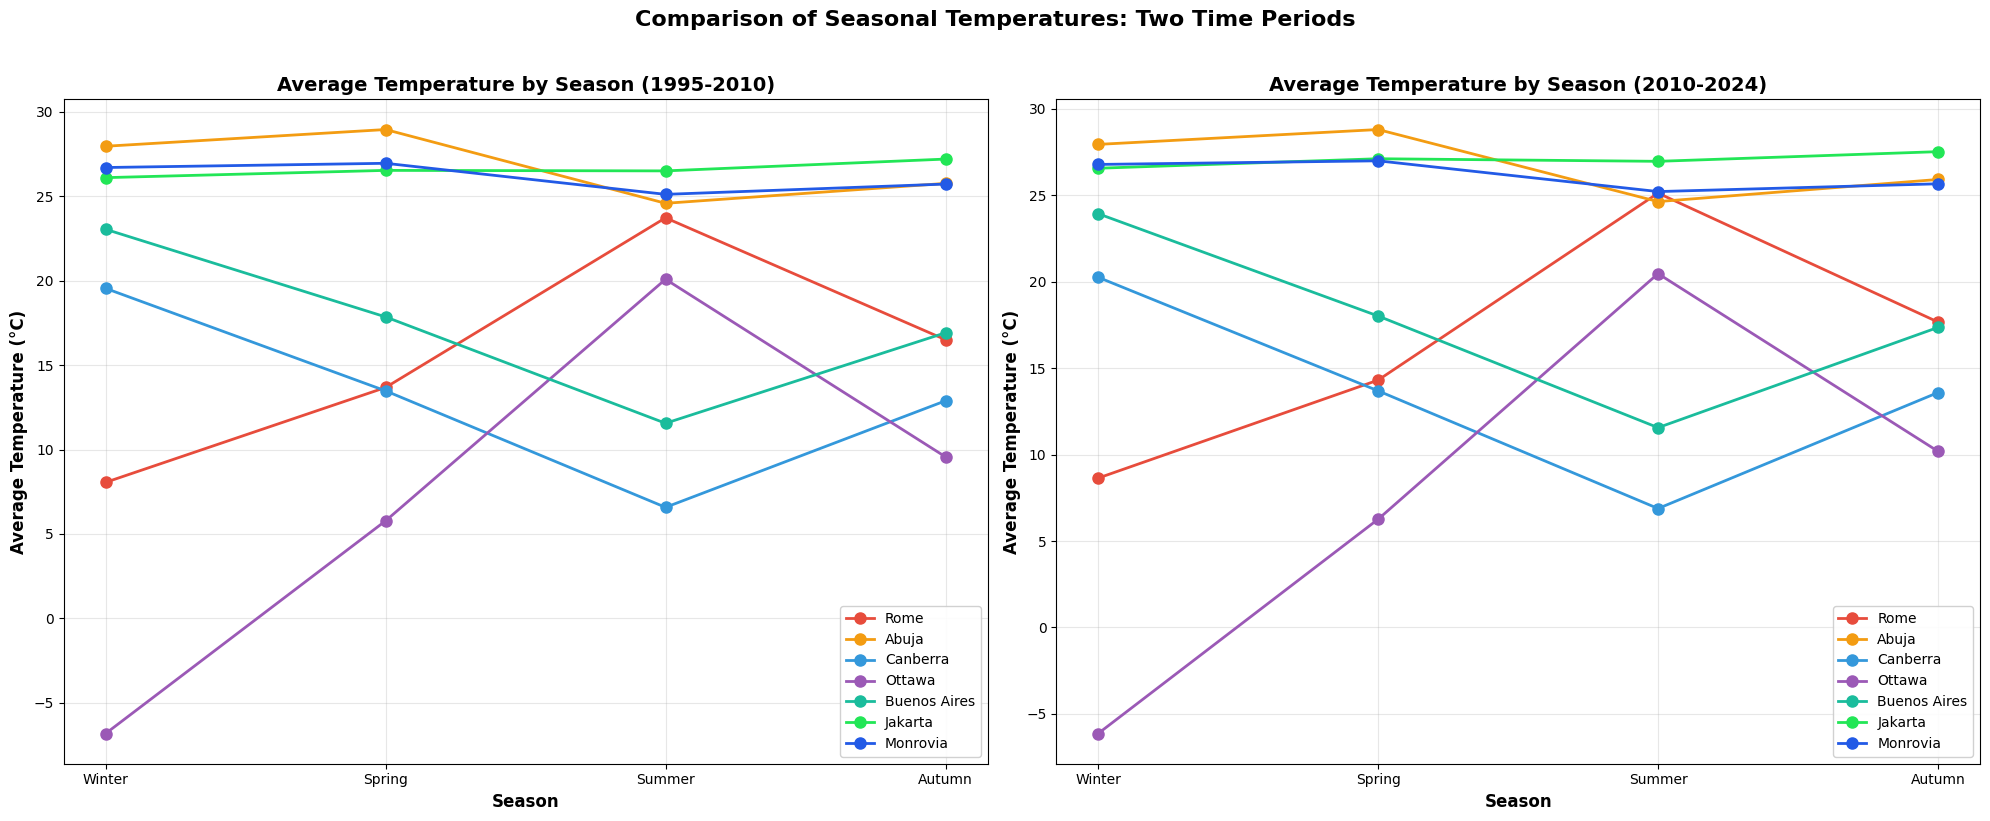

Period 1995-2009 - Average Temperatures by City and Season:
season        Autumn  Spring  Summer  Winter
capital                                     
Abuja          25.77   28.96   24.59   27.97
Buenos Aires   16.92   17.86   11.56   23.05
Canberra       12.89   13.48    6.58   19.55
Jakarta        27.21   26.54   26.51   26.11
Monrovia       25.73   26.96   25.12   26.71
Ottawa          9.57    5.78   20.09   -6.82
Rome           16.51   13.68   23.73    8.06

Period 2010-2024 - Average Temperatures by City and Season:
season        Autumn  Spring  Summer  Winter
capital                                     
Abuja          25.92   28.81   24.64   27.95
Buenos Aires   17.36   18.02   11.56   23.94
Canberra       13.59   13.69    6.88   20.26
Jakarta        27.53   27.12   26.97   26.57
Monrovia       25.67   27.00   25.22   26.79
Ottawa         10.19    6.26   20.47   -6.14
Rome           17.67   14.31   25.13    8.64

Temperature Change (2010-2024 vs 1995-2010):
season        Autumn  S

In [69]:
# Now compare average season temperature between 1995-2009 and 2010-2024

period_border = 2009

# Split data into two periods
period1 = city_year_season_stats_reset[city_year_season_stats_reset['year'] <= period_border]
period2 = city_year_season_stats_reset[city_year_season_stats_reset['year'] > period_border]

# Aggregate by city and season for each period
period1_stats = period1.groupby(['capital', 'season']).agg({
    'avg_temp_mean_c': 'mean'
}).round(2).reset_index()

period2_stats = period2.groupby(['capital', 'season']).agg({
    'avg_temp_mean_c': 'mean'
}).round(2).reset_index()

# Define season order for consistent plotting
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

# Create two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Period 1995-2010
for city in cities:
    city_data = period1_stats[period1_stats['capital'] == city]
    # Sort by season order
    city_data['season'] = pd.Categorical(city_data['season'], categories=season_order, ordered=True)
    city_data = city_data.sort_values('season')
    
    axes[0].plot(city_data['season'], city_data['avg_temp_mean_c'], 
                 marker='o', label=city.strip(), linewidth=2, markersize=8,
                 color=city_colors.get(city.strip(), None))

axes[0].set_xlabel('Season', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Temperature (°C)', fontsize=12, fontweight='bold')
axes[0].set_title('Average Temperature by Season (1995-2010)', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', framealpha=0.9, fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Period 2010-2024
for city in cities:
    city_data = period2_stats[period2_stats['capital'] == city]
    # Sort by season order
    city_data['season'] = pd.Categorical(city_data['season'], categories=season_order, ordered=True)
    city_data = city_data.sort_values('season')
    
    axes[1].plot(city_data['season'], city_data['avg_temp_mean_c'], 
                 marker='o', label=city.strip(), linewidth=2, markersize=8,
                 color=city_colors.get(city.strip(), None))

axes[1].set_xlabel('Season', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Temperature (°C)', fontsize=12, fontweight='bold')
axes[1].set_title('Average Temperature by Season (2010-2024)', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', framealpha=0.9, fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparison of Seasonal Temperatures: Two Time Periods', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print statistics for comparison
print(f"Period 1995-{period_border} - Average Temperatures by City and Season:")
print(period1_stats.pivot(index='capital', columns='season', values='avg_temp_mean_c'))
print(f"\nPeriod {period_border+1}-2024 - Average Temperatures by City and Season:")
print(period2_stats.pivot(index='capital', columns='season', values='avg_temp_mean_c'))

# Calculate temperature differences
comparison = period1_stats.merge(period2_stats, on=['capital', 'season'], 
                                  suffixes=(f'_1995_{period_border}', f'_{period_border+1}_2024'))
comparison['temp_difference'] = comparison[f'avg_temp_mean_c_{period_border+1}_2024'] - comparison[f'avg_temp_mean_c_1995_{period_border}']
print(f"\nTemperature Change ({period_border+1}-2024 vs 1995-{period_border+1}):")
print(comparison.pivot(index='capital', columns='season', values='temp_difference'))

In [70]:
# Time series plot for precipitation by season
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add a trace for each city
for city in cities:
    city_data = city_year_season_stats_reset[city_year_season_stats_reset['capital'] == city]
    
    # Create year-season column if not exists
    if 'year_season' not in city_data.columns:
        city_data['year_season'] = city_data['year'].astype(str) + '-' + city_data['season']
    
    fig.add_trace(go.Scatter(
        x=city_data['year_season'],
        y=city_data['avg_precip_mm'],
        mode='lines+markers',
        name=city.strip(),
        line=dict(width=2),
        marker=dict(size=6),
        hovertemplate='<b>%{fullData.name}</b><br>Period: %{x}<br>Avg Precipitation: %{y:.2f} mm<extra></extra>'
    ))

# Update layout
fig.update_layout(
    title='Precipitation Trends by City and Season (1995-2024)',
    xaxis_title='Year-Season',
    yaxis_title='Average Precipitation (mm)',
    hovermode='closest',
    height=600,
    width=1400,
    xaxis=dict(tickangle=-90),
    legend=dict(x=1.02, y=1, bordercolor="Black", borderwidth=1)
)

fig.show()

C:\Users\gabri\AppData\Local\Temp\ipykernel_18672\1611887464.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gabri\AppData\Local\Temp\ipykernel_18672\1611887464.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gabri\AppData\Local\Temp\ipykernel_18672\1611887464.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

C:\Users\gabri\AppData\Local\Temp\ipykernel_18672\3298157198.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



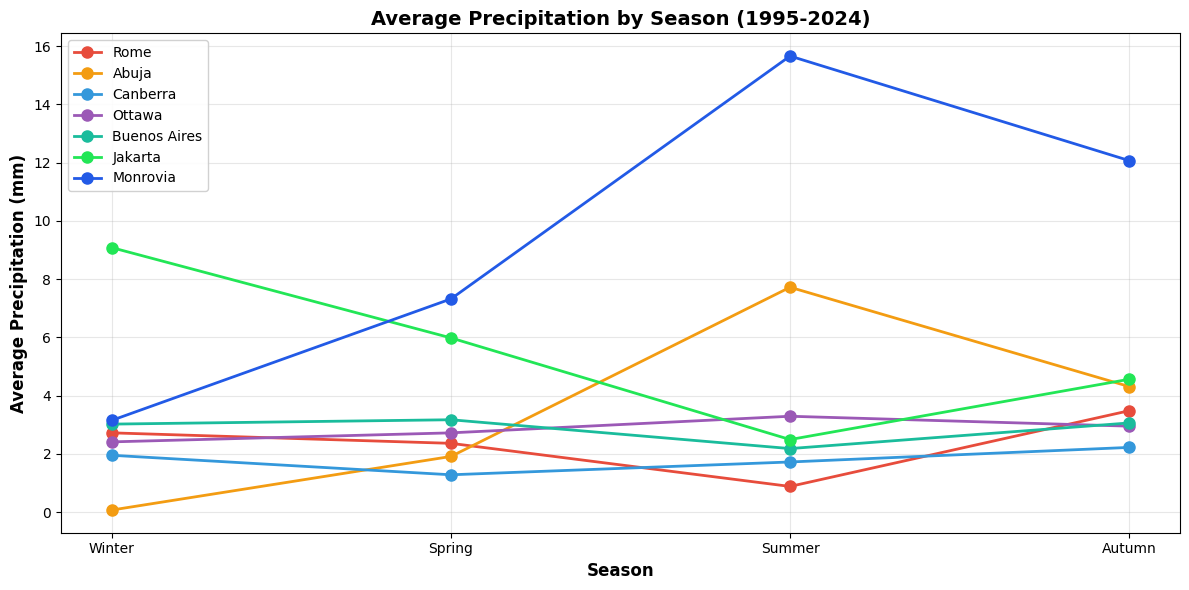

In [71]:
# Precipitation by season plot
plt.figure(figsize=(12, 6))

for city in cities:
    city_data = city_season_stats_reset[city_season_stats_reset['capital'] == city]
    # Sort by season order
    city_data['season'] = pd.Categorical(city_data['season'], categories=season_order, ordered=True)
    city_data = city_data.sort_values('season')
    
    plt.plot(city_data['season'], city_data['avg_precip_mm'], 
             marker='o', label=city.strip(), linewidth=2, markersize=8,
             color=city_colors.get(city.strip(), None))

plt.xlabel('Season', fontsize=12, fontweight='bold')
plt.ylabel('Average Precipitation (mm)', fontsize=12, fontweight='bold')
plt.title('Average Precipitation by Season (1995-2024)', fontsize=14, fontweight='bold')
plt.legend(loc='best', framealpha=0.9, fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

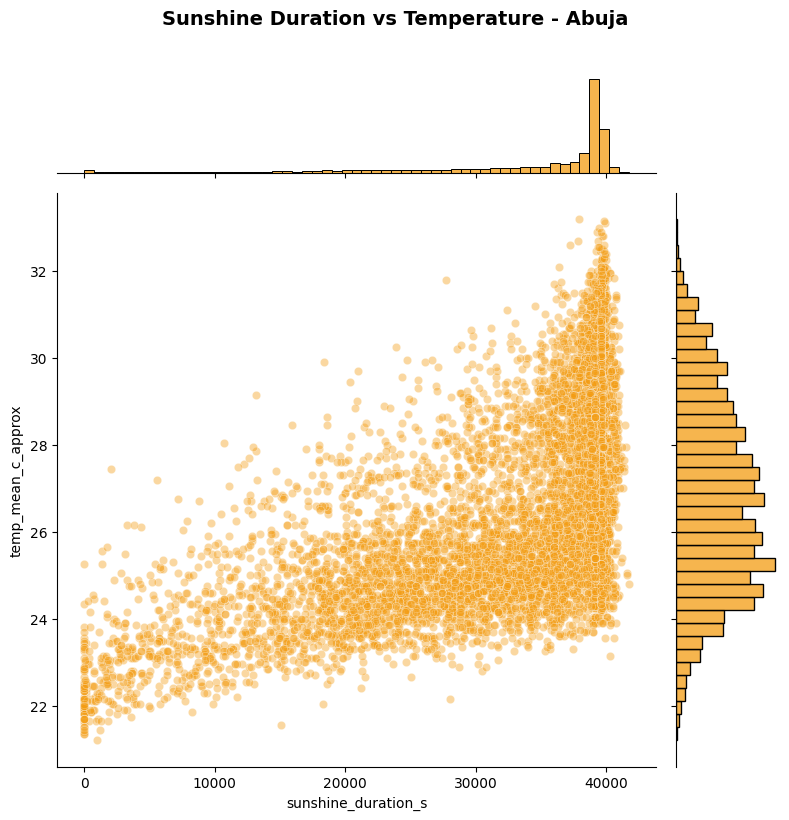

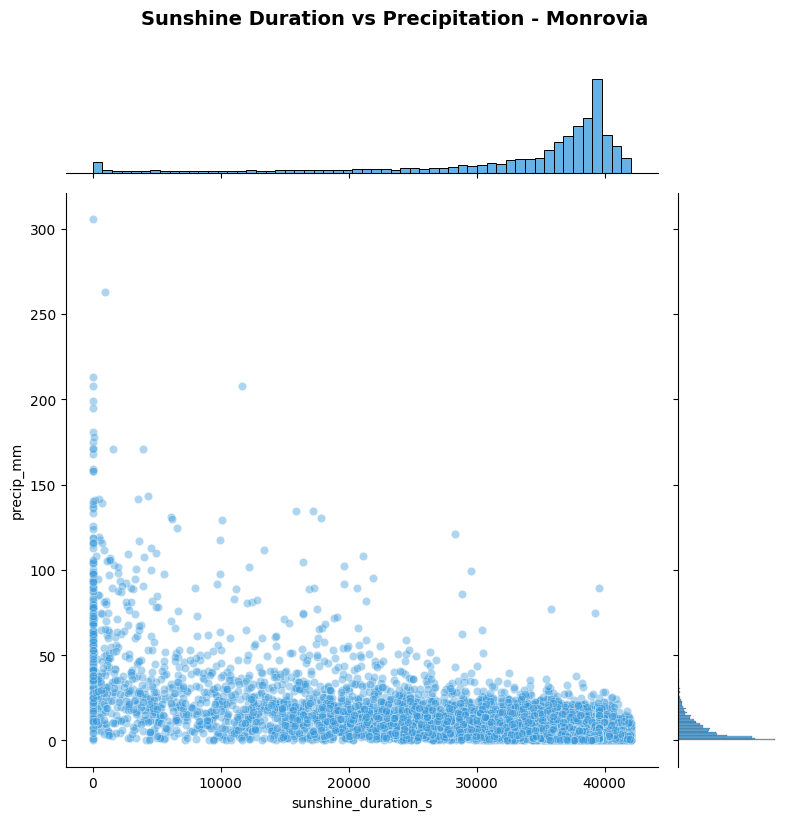


Correlation Analysis:
Sunshine Duration vs Temperature: 0.6176
Sunshine Duration vs Precipitation: -0.6119


In [ ]:
# Correletaions for Abuja and Monrovia

# Filter data for Abuja only
df_abuja = df_cities[df_cities['capital'] == 'Abuja']
df_monrovia = df_cities[df_cities['capital'] == 'Monrovia']

# Jointplot 1: Sunshine Duration vs Temperature for Abuja
sns.jointplot(data=df_abuja, x='sunshine_duration_s', y='temp_mean_c_approx', 
              kind='scatter', alpha=0.4, height=8, color='#F39C12')
plt.suptitle('Sunshine Duration vs Temperature - Abuja', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Jointplot 2: Sunshine Duration vs Precipitation for Abuja
sns.jointplot(data=df_monrovia, x='sunshine_duration_s', y='precip_mm', 
              kind='scatter', alpha=0.4, height=8, color='#3498DB')
plt.suptitle('Sunshine Duration vs Precipitation - Monrovia', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlation statistics
print("\nCorrelation Analysis:")
print(f"Sunshine Duration vs Temperature: {df_abuja[['sunshine_duration_s', 'temp_mean_c_approx']].corr().iloc[0, 1]:.4f}")
print(f"Sunshine Duration vs Precipitation: {df_monrovia[['sunshine_duration_s', 'precip_mm']].corr().iloc[0, 1]:.4f}")


In [ ]:
# Snowy data

# Calculate average and sum of snow per capital
snow_per_capital = df.groupby('capital')['snow_mm'].agg(['mean', 'sum']).sort_values('mean', ascending=False)

print("Top 10 capitals by average snowfall:")
print(snow_per_capital.head(10))

# Select TOP 3 capitals with highest snowfall
snowy_capitals = snow_per_capital.head(3).index.tolist()

print(f"\nTop 3 capitals with most snow: {snowy_capitals}")

# Filter dataframe for snowy capitals
df_snowy = df[df['capital'].isin(snowy_capitals)]

Top 10 capitals by average snowfall:
                      mean      sum
capital                            
Nuuk              0.820152  8987.23
Vaduz             0.549996  6026.86
Sarajevo          0.481587  5277.23
Reykjavík         0.477448  5231.87
Ottawa            0.414647  4543.70
Oslo              0.375124  4110.61
Moscow            0.326594  3578.82
Helsinki          0.325432  3566.08
Bishkek           0.281718  3087.07
Andorra la Vella  0.281393  3083.50

Top 3 capitals with most snow: ['Nuuk', 'Vaduz', 'Sarajevo']

Snow statistics for top 3:
              mean      sum
capital                    
Nuuk      0.820152  8987.23
Vaduz     0.549996  6026.86
Sarajevo  0.481587  5277.23


C:\Users\gabri\AppData\Local\Temp\ipykernel_18672\2614157230.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Yearly snow statistics for top 3 capitals:
  capital  year      mean     sum
0    Nuuk  1995  0.684082  249.69
1    Nuuk  1996  1.290410  472.29
2    Nuuk  1997  0.760027  277.41
3    Nuuk  1998  0.932247  340.27
4    Nuuk  1999  0.905014  330.33
5    Nuuk  2000  0.984208  360.22
6    Nuuk  2001  0.942986  344.19
7    Nuuk  2002  0.515123  188.02
8    Nuuk  2003  0.722630  263.76
9    Nuuk  2004  0.991475  362.88


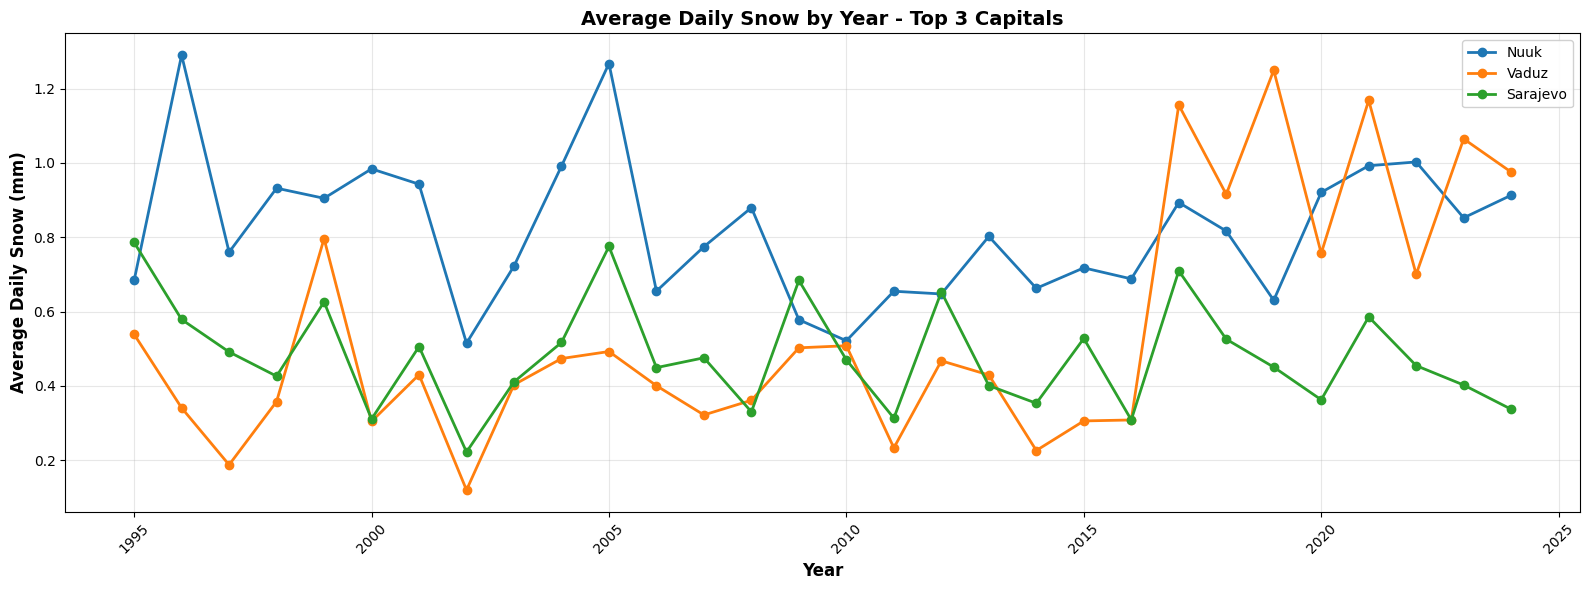

<Figure size 1000x600 with 0 Axes>

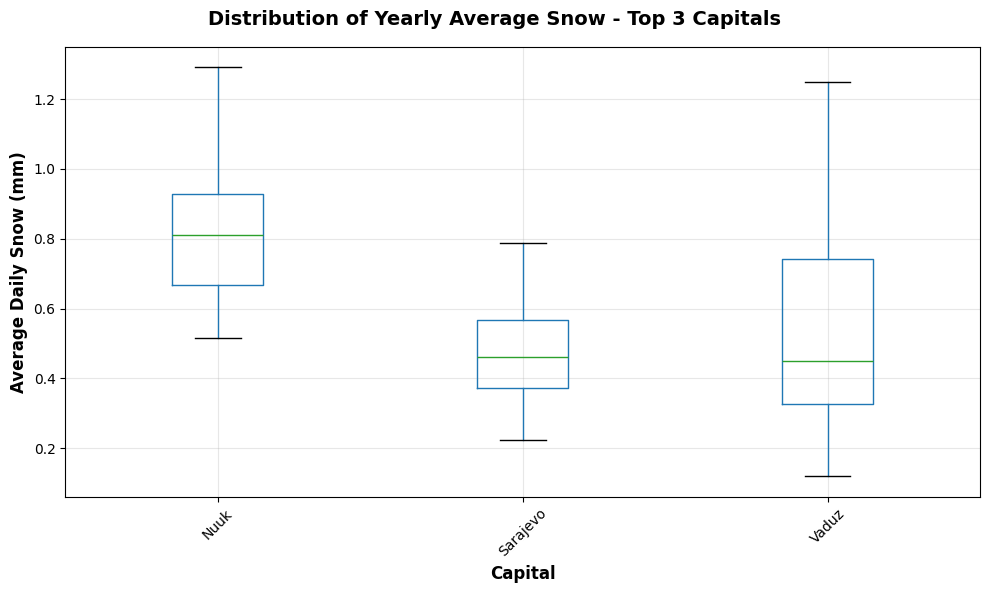


Summary of yearly average snow by capital:
          count      mean       std       min       25%       50%       75%  \
capital                                                                       
Nuuk       30.0  0.820083  0.190471  0.515123  0.668116  0.809699  0.929410   
Sarajevo   30.0  0.481628  0.143995  0.222274  0.372364  0.462479  0.566146   
Vaduz      30.0  0.550034  0.316548  0.119863  0.326753  0.448990  0.742698   

               max  
capital             
Nuuk      1.290410  
Sarajevo  0.786301  
Vaduz     1.249644  


In [78]:
# Add year column to df_snowy
df_snowy['year'] = df_snowy['date'].dt.year

# Aggregate average snow per capital and year
snow_yearly_stats = df_snowy.groupby(['capital', 'year'])['snow_mm'].agg(['mean', 'sum']).reset_index()

print("Yearly snow statistics for top 3 capitals:")
print(snow_yearly_stats.head(10))

# Create boxplots: one boxplot per year showing distribution across the 3 capitals
years = sorted(df_snowy['year'].unique())
num_years = len(years)

# Option 2: Average snow per year - Line plot
plt.figure(figsize=(16, 6))

for capital in snowy_capitals:
    capital_data = snow_yearly_stats[snow_yearly_stats['capital'] == capital]
    plt.plot(capital_data['year'], capital_data['mean'], 
             marker='o', label=capital, linewidth=2, markersize=6)

plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Average Daily Snow (mm)', fontsize=12, fontweight='bold')
plt.title('Average Daily Snow by Year - Top 3 Capitals', fontsize=14, fontweight='bold')
plt.legend(loc='best', framealpha=0.9, fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Option 3: Boxplot showing distribution of yearly averages per capital
plt.figure(figsize=(10, 6))
snow_yearly_stats.boxplot(column='mean', by='capital', rot=45, figsize=(10, 6))
plt.suptitle('Distribution of Yearly Average Snow - Top 3 Capitals', 
             fontsize=14, fontweight='bold')
plt.title('')
plt.xlabel('Capital', fontsize=12, fontweight='bold')
plt.ylabel('Average Daily Snow (mm)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary of yearly average snow by capital:")
print(snow_yearly_stats.groupby('capital')['mean'].describe())

# Geo DATA

In [ ]:
#We plot world and we color each country depending on the variation on temperature it has from hottest month to coldest month